This notebook attempts to validate the findings of entrenchment of specific sites (38, 55 etc) between v families or v genes using DASM using raw counts.

We do this by calculating the mutation rate on either productive or non productive data, referenced in the notebook as total mutation rate and neutral mutation rate respectively. The ratio between them should be the DNSM/DASM selection factors.

The mutation rate is calculated in the following manner:
- The rate is calculated as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites.
- rate = number of mutations / branch length per v-family, focusing on IGHV1, IGHV3, IGHV4. Branch length is calulated in two ways: using the iqtree branch length, and by number of mutations on branch / sequence length. The resulting rates are termed "rate" and "rate_mutcount", with the analysis focused on "rate_mutcount" to be consistent with thrifty calculations.

The analysis is preformed both per site, consistent with DNSM data, and per site+parent_aa+child_aa, consistent with DASM.

The calculation is performed on pcps and relies on previous code:
- For productive data, site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For non productive data, we adapted code from thrifty-experiments-1 to create a dataframe with the occurence of mutations per pcp pair. As non productive data has frameshifts in the VDJ area, the V gene area should be consistent with the germline v gene, and so we can add IMGT numbering and germline annotations to this.


Results:
- Both DNSM and DASM results align with the selection factors calculated from the rates. I specifically highlighted sites that came up as interesting in the entrenchment analysis (vj_families_dasm) and they seem to be similar between the raw rates and the model's predictions (cells 8 and 13).
- Looking at the neutral mutation rates per site (cell 9), we see that sites of interest (38,40,55,57,66) all have high neutral mutation rates, which is also what thrifty had shown (neutral_rates_for_interesting_sites).


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED
from netam.framework import encode_mut_pos_and_base

from shmex.shm_data import pcp_df_of_non_shmoof_nickname

from dnsmex.dasm_oe import write_sites_oe
from dnsmex.local import localify

from utils import add_column_aa_one_mutation_away_from_aa


In [2]:
# functions for comparing mutation rates across different V gene families using count data

def compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']):
    '''
    Calculate mutation rates at a specific site across different V gene families.
    
    This function analyzes mutation rates at a given site across different V families,
    using branch length as a measure of evolutionary time.
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame containing site substitution probabilities with columns:
        - 'site': site position
        - 'sample_id': sample identifier
        - 'family': family identifier
        - 'pcp_index': phylogenetic branch identifier
        - 'branch_length': evolutionary distance (substitutions per site)
        - 'germline_amino_acid': original amino acid at germline
        - 'is_germline_aa': boolean indicating if current AA matches germline
        - 'mutation': boolean indicating if site is mutated from germline
        - 'mutations_per_branch': total mutations accumulated on this branch
    
    vfamilies : list
        List of V gene families to compare (default: ['IGHV1', 'IGHV3', 'IGHV4'])
    site : int
        Site position to analyze
        
    Returns:
    --------
    list
        List of dictionaries containing mutation rate data for each V family:
        - 'vfamily': V gene family name
        - 'site': site position
        - 'branch_length': total branch length
        - 'mutations_per_branch': total mutations per branch
        - 'mutation_acquired': number of mutations acquired
        - 'rate': mutations per unit branch length
        - 'rate_mutcount': mutations per mutation count
        
    Notes:
    ------
    - Only analyzes branches where the site has germline amino acid identity
    - Handles cases with zero branch length or mutation count
    - Calculates both branch-length normalized and mutation-count normalized rates
    '''

    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site) & (site_sub_probs_df_germline.v_family.isin(vfamilies))].copy()
    
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]

    vfamily_results = []
    vfamily_results_per_aa = []
    for vfamily in vfamilies:
        # filter for the current V family and only branches that have the germline amino acid at site
        vfamily_df = cur_df[(cur_df['v_family'] == vfamily) & (cur_df.is_germline_aa == True)].copy()
        if vfamily_df.empty:
            print(f"No data for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates for the current V family
        length = vfamily_df['branch_length'].sum()
        length_mutcount = vfamily_df['mutation_freq_branch'].sum()

        mutation_acquired = len(vfamily_df[(vfamily_df['mutation'] == True)])

        if length == 0:
            print(f"Zero branch length or mutation count for V family {vfamily} at site {site}")
            continue
        if length_mutcount == 0:
            print(f"Zero mutation count for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates
        rate = mutation_acquired / length
        rate_mutcount = mutation_acquired / length_mutcount
        vfamily_results.append({
            'v_family': vfamily,
            'site': site,
            'branch_length': length,
            'mutcount_length': length_mutcount,
            'mutation_acquired': mutation_acquired,
            'rate': rate,
            'rate_mutcount': rate_mutcount
        })


        # calculate aa specific rates
        for amino_acid in vfamily_df['germline_amino_acid'].unique():
            aa_df = vfamily_df[vfamily_df['parent_aa'] == amino_acid]
            aa_length = aa_df['branch_length'].sum()
            aa_length_mutcount = aa_df['mutation_freq_branch'].sum()

            if aa_df.empty:
                continue

            for target_amino_acid in AA_STR_SORTED:
                if amino_acid != target_amino_acid:
                    aa_mutation_acquired = len(aa_df[(aa_df['mutation'] == True) & (aa_df['child_aa'] == target_amino_acid)])
                    
                    # Calculate mutation rates for the specific amino acid
                    rate_aa = aa_mutation_acquired / aa_length
                    rate_aa_mutcount = aa_mutation_acquired / aa_length_mutcount

                    vfamily_results_per_aa.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_aa': amino_acid,
                        'child_aa': target_amino_acid,
                        'branch_length': aa_length,
                        'mutcount_length': aa_length_mutcount,
                        'mutation_acquired': aa_mutation_acquired,
                        'rate': rate_aa,
                        'rate_mutcount': rate_aa_mutcount
                    })

    # # Calculate totals from actual data
    # total_counts = len(cur_df[['family', 'sample_id', 'pcp_index']].drop_duplicates())
    # total_branch_length = cur_df['branch_length'].sum()
    # total_mutations_acquired = len(cur_df[(cur_df['mutation'] == True)])
    
    
    return vfamily_results, vfamily_results_per_aa


def compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline, output_path):
    """
    Calculate mutation rates for all sites across different V gene families.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with site substitution probabilities and germline info
        output_path (str): Base output path to save the results CSV files (without extension)
        
    Returns:
        tuple: (results_df, results_per_aa_df) - DataFrames with results for overall and per-AA analysis
    """
    import pandas as pd
    import os
    
    # Run for all sites
    all_results = []
    all_results_per_aa = []
    site_list = site_sub_probs_df_germline.site.unique().tolist()
    
    print(f"Processing {len(site_list)} sites...")
    
    for i, site in enumerate(site_list):
        if i % 10 == 0:  # Progress indicator
            print(f"Processing site {i+1}/{len(site_list)}: site {site}")
            
        vfamily_results, vfamily_results_per_aa = compare_mutation_rates_on_different_vfamilies(
            site_sub_probs_df_germline, site
        )
        
        # Extend the lists with results from this site
        all_results.extend(vfamily_results)
        all_results_per_aa.extend(vfamily_results_per_aa)

    # Convert to DataFrames
    print("Converting results to DataFrames...")
    results_df = pd.DataFrame(all_results)
    results_per_aa_df = pd.DataFrame(all_results_per_aa)
    
    # Generate output file paths
    base_path = output_path.replace('.csv', '')  # Remove .csv if present
    overall_output_path = f"{base_path}_overall_mutation_rates.csv"
    per_aa_output_path = f"{base_path}_per_aa_mutation_rates.csv"
    
    # Save overall results
    if not results_df.empty:
        print(f'Saving overall results to {overall_output_path}')
        results_df.to_csv(overall_output_path, index=False)
        print(f"Overall results: {len(results_df)} rows saved")
    else:
        print("Warning: No overall results to save")
    
    # Save per-amino acid results  
    if not results_per_aa_df.empty:
        print(f'Saving per-amino acid results to {per_aa_output_path}')
        results_per_aa_df.to_csv(per_aa_output_path, index=False)
        print(f"Per-AA results: {len(results_per_aa_df)} rows saved")
    else:
        print("Warning: No per-amino acid results to save")
    
    return results_df, results_per_aa_df


In [3]:
### prepare shm out of frame data
### adapted from thrifty-experiments-1

data_nickname = "tangshm"
#data_nickname = 'shmoof'
dest_dir = "_ignore/neutral_counts_from_non_productive"
os.makedirs(dest_dir, exist_ok=True)

def ragged_np_pcp_encoding(parents, children, site_count=None):
    """
    Encode the mutation indicators, base indices, and masks of a list of
    parent-child pairs.
    """
    mutation_indicator_list = []
    mask_list = []
    for parent, child in zip(parents, children):
        mutation_indicators, _ = encode_mut_pos_and_base(parent, child)
        mutation_indicator_list.append(mutation_indicators.numpy()[:site_count])
        mask_list.append(nt_mask_tensor_of(child).numpy()[:site_count])
    return mutation_indicator_list, mask_list


def detailed_site_df_for(pcp_df):
    """Create a DataFrame with every site, mutation status, branch length, v_gene, and sequence details"""
    mut_indicators, masks = ragged_np_pcp_encoding(
        pcp_df["parent"], pcp_df["child"]
    )
    val_bls = pcp_df["branch_length"].values
    
    detailed_rows = []
    
    for seq_idx, (mask, branch_length, mut_indicator, v_gene, parent_seq, child_seq) in enumerate(
        zip(masks, val_bls, mut_indicators, pcp_df["v_gene"], pcp_df["parent"], pcp_df["child"])
    ):
        
        # For each site in this sequence
        for site_idx in range(len(parent_seq)):
            if mask[site_idx]:  # Only include valid sites
                # Get nucleotides
                parent_nt = parent_seq[site_idx] if site_idx < len(parent_seq) else 'N'
                child_nt = child_seq[site_idx] if site_idx < len(child_seq) else 'N'
                
                # Get codon information (which codon this site belongs to)
                codon_idx = (site_idx // 3)
                codon_position = site_idx % 3  # Position within codon (0, 1, or 2)
                
                # Extract parent and child codons
                codon_start = codon_idx * 3
                codon_end = codon_start + 3
                
                parent_codon = parent_seq[codon_start:codon_end] if codon_end <= len(parent_seq) else 'NNN'
                child_codon = child_seq[codon_start:codon_end] if codon_end <= len(child_seq) else 'NNN'
                
                # Translate codons to amino acids
                try:
                    from Bio.Seq import Seq
                    parent_aa = str(Seq(parent_codon).translate()) if len(parent_codon) == 3 else 'X'
                    child_aa = str(Seq(child_codon).translate()) if len(child_codon) == 3 else 'X'
                except:
                    parent_aa = 'X'
                    child_aa = 'X'
                
                detailed_rows.append({
                    'pcp_index': seq_idx,
                    'nt_site': site_idx,
                    'site': codon_idx + 1,
                    'codon_position': codon_position,
                    'mutation': bool(mut_indicator[site_idx]),
                    'branch_length': branch_length,
                    'v_gene': v_gene,
                    'v_family': v_gene.split('-')[0] if '-' in str(v_gene) else v_gene,
                    'parent_nt': parent_nt,
                    'child_nt': child_nt,
                    'parent_codon': parent_codon,
                    'child_codon': child_codon,
                    'parent_aa': parent_aa,
                    'child_aa': child_aa,
                })
    
    return pd.DataFrame(detailed_rows)


def create_detailed_site_data(
    dataset_name,
):
    """
    Create detailed site-level data with mutation probabilities and observed mutations.
    
    Returns:
    - pcp_df: The parent-child pair DataFrame
    - detailed_site_df: DataFrame with every site and its mutation data
    """
    pcp_df = pcp_df_of_non_shmoof_nickname(dataset_name)

    # Create detailed site data for all sequences
    detailed_site_list = []
    
    # All data
    detailed_all = detailed_site_df_for(pcp_df)
    detailed_site_list.append(detailed_all)
    
    # Combine all detailed data
    detailed_site_df = pd.concat(detailed_site_list, ignore_index=True)
    
    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False)['site'].rank(method='dense').astype(int)
    detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank', 'mutation_occurred':'mutation'}), germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}), on=['v_family', 'v_gene', 'rank'], how='left')
    detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['germline_codon']
    detailed_site_df_germline['is_germline_aa'] = detailed_site_df_germline['parent_aa'] == detailed_site_df_germline['germline_amino_acid']

    # mutations frequency per branch as an alternative to branch length
    detailed_site_df_germline['mutations_per_branch'] = detailed_site_df_germline.groupby('pcp_index')['mutation'].transform('sum')
    detailed_site_df_germline['seq_length'] = detailed_site_df_germline.groupby('pcp_index').transform('size')
    detailed_site_df_germline['mutation_freq_branch'] = detailed_site_df_germline['mutations_per_branch'] / detailed_site_df_germline['seq_length']

    
    # collapse for site level analysis
    detailed_site_df_germline_per_site = detailed_site_df_germline.groupby(['pcp_index',
       'branch_length', 'v_gene', 'v_family',
       'parent_codon', 'child_codon', 'parent_aa', 'child_aa', 'site',
       'germline_codon', 'germline_amino_acid', 'is_germline_codon',
       'is_germline_aa', 'mutations_per_branch', 'seq_length', 'mutation_freq_branch'])['mutation'].any().reset_index().sort_values(by=['pcp_index', 'site'])


    return pcp_df, detailed_site_df_germline, detailed_site_df_germline_per_site


# Create the detailed site data
pcp_df_neutral, detailed_nuc_site_df_neutral, detailed_site_df_neutral = create_detailed_site_data(
    dataset_name=data_nickname,
)

Loading /home/nharel/data/v1/tang-deepshm-oof_pcp_2024-04-09_MASKED_NI.csv.gz
Loaded 7000 PCPs from tangshm


In [9]:
## load and perpare data for total mutation rates using counts


def load_or_create_datafile(dataset_name, remove_leaves=True):
    model_name = "dnsm_1m-v1jaffe+v1tang-joint"

    crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

    try:
        site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
        pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


    except FileNotFoundError:
        if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
            dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


        complete_plotter, plotter_dict = write_sites_oe(
            crepe_prefix=crepe_prefix,
            dataset_name=dataset_name,
            branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
            csv_output_path=f"{test_output_prefix}-sites-oe.csv",
            fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
            min_log_prob=-4,
            replace_title=True,
        )
        complete_plotter = complete_plotter["heavy"]


        pcp_df = complete_plotter.pcp_df.copy()
        site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
        for column_name in ['selection_factor', 'neutral_prob', 'prob']:
            site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


        pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
        site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name', 'child_is_leaf']]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

    site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
    site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
    site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon

    # mutations frequency per branch as an alternative to branch length
    site_sub_probs_df_germline['mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['mutation'].transform('sum')
    site_sub_probs_df_germline['seq_length'] = site_sub_probs_df_germline.groupby('pcp_index').transform('size')
    site_sub_probs_df_germline['mutation_freq_branch'] = site_sub_probs_df_germline['mutations_per_branch'] / site_sub_probs_df_germline['seq_length']


    if remove_leaves:
        print("Removing leaf nodes from the analysis")
        site_sub_probs_df_germline = site_sub_probs_df_germline[~site_sub_probs_df_germline['child_is_leaf']]

    return site_sub_probs_df_germline, pcp_df


site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1rodriguez')

#site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1tang')


Removing leaf nodes from the analysis


In [5]:
## calculate total and neutral mutation rates

compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total,  '_ignore/total_counts_from_productive/total_mutation_rates.csv')
compare_mutation_rates_on_different_backgrounds_for_all_sites(detailed_site_df_neutral,  '_ignore/neutral_counts_from_non_productive/total_mutation_rates.csv')

Processing 144 sites...
Processing site 1/144: site 1.0
Processing site 11/144: site 12.0
Processing site 21/144: site 22.0
No data for V family IGHV1 at site 31.0
No data for V family IGHV3 at site 31.0
Processing site 31/144: site 34.0
No data for V family IGHV1 at site 34.0
No data for V family IGHV3 at site 34.0
Processing site 41/144: site 44.0
Processing site 51/144: site 54.0
No data for V family IGHV1 at site 60.0
No data for V family IGHV4 at site 60.0
No data for V family IGHV1 at site 61.0
No data for V family IGHV4 at site 61.0
No data for V family IGHV4 at site 62.0
Processing site 61/144: site 64.0
Processing site 71/144: site 75.0
Processing site 81/144: site 85.0
Processing site 91/144: site 95.0
Processing site 101/144: site 105.0
No data for V family IGHV1 at site 107.0
No data for V family IGHV4 at site 107.0
No data for V family IGHV1 at site 108.0
No data for V family IGHV3 at site 108.0
No data for V family IGHV4 at site 108.0
No data for V family IGHV1 at site 10

(    v_family   site  branch_length  mutcount_length  mutation_acquired  \
 0      IGHV1    1.0      29.074613        26.602185                 14   
 1      IGHV3    1.0      64.881062        58.361661                141   
 2      IGHV4    1.0      29.386861        26.840527                 20   
 3      IGHV1    2.0      27.874900        25.475286                 36   
 4      IGHV3    2.0      65.209761        58.681757                 67   
 ..       ...    ...            ...              ...                ...   
 293    IGHV3   60.0       5.880572         5.356575                 30   
 294    IGHV3   61.0       5.174587         4.693421                 16   
 295    IGHV4   31.0      13.891178        12.650727                 60   
 296    IGHV4   34.0      10.591267         9.663507                 32   
 297    IGHV3  107.0       1.682318         1.570720                  7   
 
          rate  rate_mutcount  
 0    0.481520       0.526273  
 1    2.173207       2.415970  
 2

## Fetch entrenchment sites

In [ ]:
highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 42: 'purple', 57: 'blue', 64: 'cyan', 66: 'magenta', 56:'brown', 106:'pink'}


## Choose specific sites and amino acids per v family from the entrenchment dasm analysis
entrenchment_directory = '_output/entrenchment_analysis/'
entrenchement_dfs = []
for f in os.listdir(entrenchment_directory):
    if 'within' in f:
        entrenchment_df = pd.read_csv(os.path.join(entrenchment_directory, f))
        entrenchement_dfs.append(entrenchment_df)

entrenchement_dfs = pd.concat(entrenchement_dfs, axis=0)

## Rates per site (any aa to any aa)
- First let's compare do DNSM to see that this makes sense. Compare well.
- Second - look at intersting sites (38, 55 etc). They seem to have a very high neutral rate, together with a pretty low total mutation rate.



In [10]:
total_df = pd.read_csv('_ignore/total_counts_from_productive/total_mutation_rates_overall_mutation_rates.csv')
neutral_df = pd.read_csv('_ignore/neutral_counts_from_non_productive/total_mutation_rates_overall_mutation_rates.csv')

In [11]:
# compare dnsm log selection factors and log rate ratio of counts (total / neutral)
# aggregate by v_family and site

dnsm_summarized = site_sub_probs_df_germline_total[site_sub_probs_df_germline_total.is_germline_aa == True].groupby(['v_family', 'site']).selection_factor.median().reset_index()
dnsm_summarized['log_selection_factor'] = np.log(dnsm_summarized['selection_factor'])
dnsm_summarized['log_selection_factor'] = dnsm_summarized['log_selection_factor'].clip(lower=-4, upper=4)

rates_summarized = pd.merge(
    total_df[['v_family', 'site', 'mutcount_length','mutation_acquired','rate_mutcount']], 
    neutral_df[['v_family', 'site', 'mutcount_length','mutation_acquired','rate_mutcount']], 
    on=['site', 'v_family'],
    suffixes=('_total', '_neutral')
)

rates_summarized['ratio'] = (rates_summarized['rate_mutcount_total'] + 1e-5) / (rates_summarized['rate_mutcount_neutral'] + 1e-5)
rates_summarized['log_ratio'] = np.log(rates_summarized['ratio'])
rates_summarized['log_ratio'] = rates_summarized['log_ratio'].clip(lower=-4, upper=4)

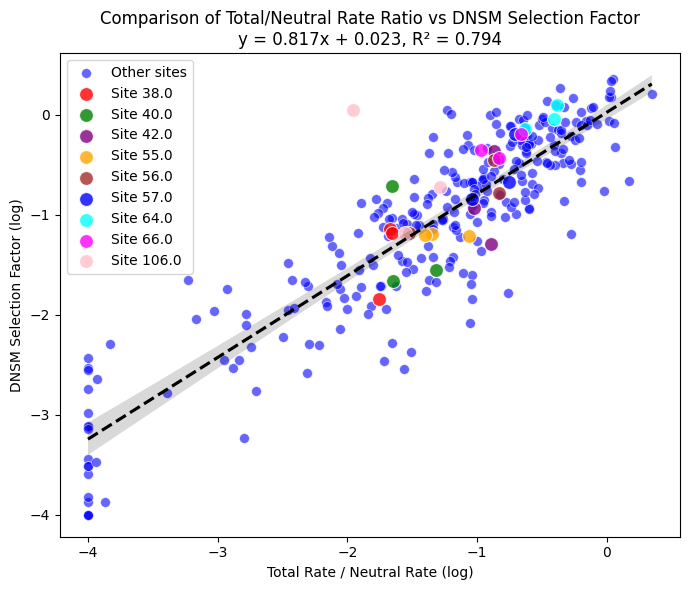

In [ ]:
compare_rates_dnsm = pd.merge(rates_summarized, dnsm_summarized, on=['v_family', 'site'])

# Calculate regression statistics
x = compare_rates_dnsm['log_ratio']
y = compare_rates_dnsm['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2

# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))


# Create mask for regular points (not in highlight list)
mask_regular = ~compare_rates_dnsm['site'].isin(highlight_sites.keys())

# Plot regular points in blue
sns.scatterplot(data=compare_rates_dnsm[mask_regular], 
                x='log_ratio', y='log_selection_factor', 
                color='blue', alpha=0.6, s=50, label='Other sites')

# Plot each highlighted site with its own color
highlighted_data = pd.merge(compare_rates_dnsm, entrenchement_dfs[['site', 'v_family']].drop_duplicates(), on=['site', 'v_family'], how='inner')

for site in highlighted_data.site.drop_duplicates().tolist():
    mask_site = compare_rates_dnsm['site'] == site
    color = highlight_sites.get(site, 'black')  # Default to black if not found
    if mask_site.any():  # Only plot if the site exists in the data
        sns.scatterplot(data=compare_rates_dnsm[mask_site], 
                        x='log_ratio', y='log_selection_factor', 
                        color=color, s=100, alpha=0.8, label=f'Site {site}')

# Add the regression line
sns.regplot(data=compare_rates_dnsm, x='log_ratio', y='log_selection_factor', 
            scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

# Add legend
plt.legend()

plt.xlabel('Total Rate / Neutral Rate (log)')
plt.ylabel('DNSM Selection Factor (log)')

# Format the equation and R² for the title
if intercept >= 0:
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
else:
    equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

title = f'Comparison of Total/Neutral Rate Ratio vs DNSM Selection Factor\n{equation}, R² = {r_squared:.3f}'
plt.title(title)

plt.tight_layout()
plt.show()

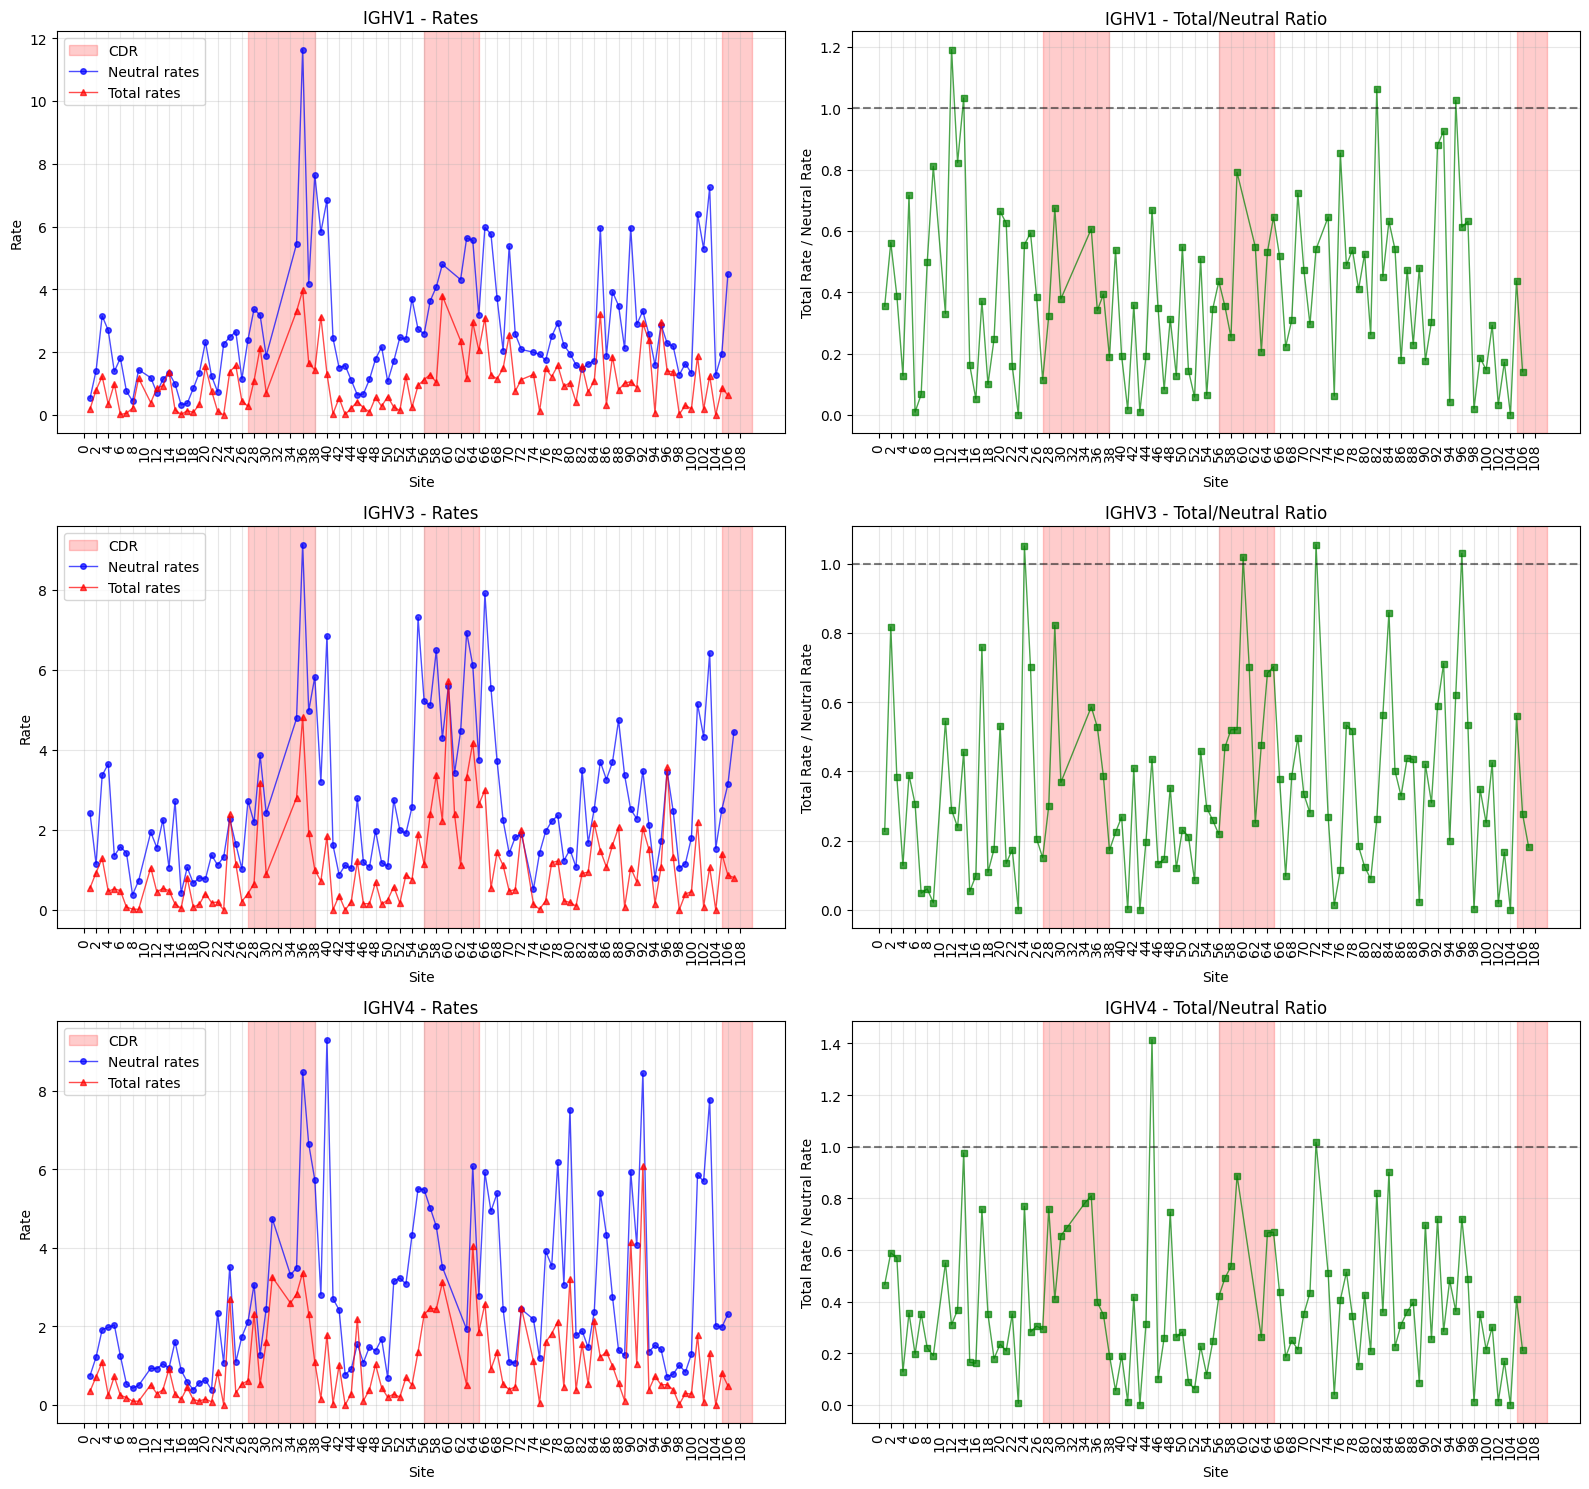

In [9]:
# plot the rates and rate ratio (total / neutral) for each v_family


fig, axes = plt.subplots(3, 2, figsize=(16, 15))
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

# Define CDR regions (approximate IMGT positions)
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (approximate, can vary) (shortened, just because looking nonly at v genes)
]

for i, v_family in enumerate(v_families):
    # Left column - rates
    ax_rates = axes[i, 0]
    
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        ax_rates.axvspan(cdr_start, cdr_end, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")
    
    # Filter and sort data for this v_family
    neutral_df_family = neutral_df[neutral_df['v_family'] == v_family].sort_values('site')
    total_df_family = total_df[total_df['v_family'] == v_family].sort_values('site')
    
    # Plot neutral rates
    ax_rates.plot(neutral_df_family['site'], neutral_df_family['rate_mutcount'], 
           'o-', alpha=0.7, label='Neutral rates', color='blue', markersize=4, linewidth=1)
    
    # Plot total rates
    ax_rates.plot(total_df_family['site'], total_df_family['rate_mutcount'], 
           '^-', alpha=0.7, label='Total rates', color='red', markersize=4, linewidth=1)
    
    # Formatting for rates column
    ax_rates.set_title(f'{v_family} - Rates')
    ax_rates.set_xlabel('Site')
    ax_rates.set_ylabel('Rate')
    ax_rates.legend()
    ax_rates.grid(True, alpha=0.3)
    
    # Set x-ticks every second value and rotate labels
    if len(neutral_df_family) > 0:
        ax_rates.set_xticks(np.arange(0, 110, 2))  # Every second site
        ax_rates.tick_params(axis='x', rotation=90)  # Rotate x-tick labels
    
    # Right column - ratio
    ax_ratio = axes[i, 1]
    
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        ax_ratio.axvspan(cdr_start, cdr_end, alpha=0.2, color='red', label='CDR' if cdr_start == cdr_regions[0][0] else "")
    
    # Merge data to calculate ratios at matching sites
    merged_family = pd.merge(
        total_df_family[['site', 'rate_mutcount']], 
        neutral_df_family[['site', 'rate_mutcount']], 
        on='site', 
        suffixes=('_total', '_neutral')
    )
    
    # Calculate ratio (avoiding division by zero)
    merged_family['ratio'] = merged_family['rate_mutcount_total'] / merged_family['rate_mutcount_neutral'].replace(0, np.nan)
    
    # Plot ratio
    ax_ratio.plot(merged_family['site'], merged_family['ratio'], 
           's-', alpha=0.7, color='green', markersize=4, linewidth=1)
    
    # Add horizontal line at y=1 for reference
    ax_ratio.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
    # Formatting for ratio column
    ax_ratio.set_title(f'{v_family} - Total/Neutral Ratio')
    ax_ratio.set_xlabel('Site')
    ax_ratio.set_ylabel('Total Rate / Neutral Rate')
    ax_ratio.grid(True, alpha=0.3)
    
    # Set x-ticks every second value and rotate labels
    if len(merged_family) > 0:
        ax_ratio.set_xticks(np.arange(0, 110, 2))  # Every second site
        ax_ratio.tick_params(axis='x', rotation=90)  # Rotate x-tick labels

plt.tight_layout()
plt.show()

## Rates per site, parent aa and child aa
- First let's compare do DASM to see that this makes sense.
- Second - look at intersting sites (38, 55 etc). And see that they line up.



In [14]:
total_aa_df = pd.read_csv('_ignore/total_counts_from_productive/total_mutation_rates_per_aa_mutation_rates.csv')
neutral_aa_df = pd.read_csv('_ignore/neutral_counts_from_non_productive/total_mutation_rates_per_aa_mutation_rates.csv')

add_column_aa_one_mutation_away_from_aa(total_aa_df, 'parent_aa', 'child_aa')
add_column_aa_one_mutation_away_from_aa(neutral_aa_df, 'parent_aa', 'child_aa')

Adding one_mutation_away column: 100%|██████████| 10317/10317 [00:00<00:00, 234543.84it/s]


In [15]:
# Merge data to calculate ratios at matching sites and AA changes
rates_aa_summarized = pd.merge(
        total_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount', 'mutcount_length', 'mutation_acquired', 'v_family', 'one_mutation_away']], 
        neutral_aa_df[['site', 'parent_aa', 'child_aa', 'rate_mutcount',  'mutcount_length', 'mutation_acquired', 'v_family', 'one_mutation_away']], 
        on=['site', 'parent_aa', 'child_aa', 'v_family', 'one_mutation_away'], 
        suffixes=('_total', '_neutral')
    )

rates_aa_summarized['ratio'] = (rates_aa_summarized['rate_mutcount_total'] + 1e-5) / (rates_aa_summarized['rate_mutcount_neutral'] + 1e-5)
rates_aa_summarized['log_ratio'] = np.log(rates_aa_summarized['ratio'])

In [16]:
### compare to DASM

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)


# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'depth', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
germline_codons_df['site'] = germline_codons_df['site'].astype(float)
aa_site_subs_selection_df_germline = pd.merge(aa_site_subs_selection_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
aa_site_subs_selection_df_germline['is_germline_aa'] = aa_site_subs_selection_df_germline.parent_aa == aa_site_subs_selection_df_germline.germline_amino_acid
aa_site_subs_selection_df_germline['is_germline_codon'] = aa_site_subs_selection_df_germline.parent_codon == aa_site_subs_selection_df_germline.germline_codon


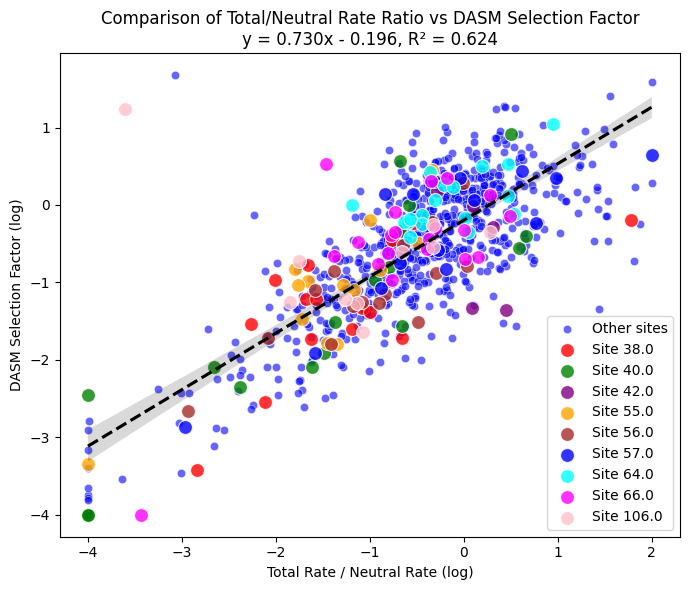

In [21]:

dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


compare_dasm_rates = pd.merge(rates_aa_summarized, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

# filter only sites with sufficient data, and one mutation away
compare_dasm_rates = compare_dasm_rates[(compare_dasm_rates['mutation_acquired_total'] + compare_dasm_rates['mutation_acquired_neutral'] > 20) & (compare_dasm_rates.one_mutation_away == True)]    



# Calculate regression statistics
x = compare_dasm_rates['log_ratio']
y = compare_dasm_rates['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2

# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))

# Create mask for regular points (not in highlight list)
mask_regular = ~compare_dasm_rates['site'].isin(highlight_sites.keys())

# Plot regular points in blue
sns.scatterplot(data=compare_dasm_rates[mask_regular], 
                x='log_ratio', y='log_selection_factor', 
                color='blue', alpha=0.6, label='Other sites')

# Plot each highlighted site with its own color

# Plot each highlighted site with its own color
highlighted_data = pd.merge(compare_dasm_rates, entrenchement_dfs[['site', 'v_family', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename({'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), on=['site', 'v_family'], how='inner')

for site in highlighted_data.site.drop_duplicates().tolist():
    mask_site = compare_dasm_rates['site'] == site
    color = highlight_sites.get(site, 'black')  # Default to black if not found
    if mask_site.any():  # Only plot if the site exists in the data
        sns.scatterplot(data=compare_dasm_rates[mask_site], 
                        x='log_ratio', y='log_selection_factor', 
                        color=color, s=100, alpha=0.8, label=f'Site {site}')

# Add the regression line
sns.regplot(data=compare_dasm_rates, x='log_ratio', y='log_selection_factor', 
            scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

# Add legend
plt.legend()

plt.xlabel('Total Rate / Neutral Rate (log)')
plt.ylabel('DASM Selection Factor (log)')

# Format the equation and R² for the title
if intercept >= 0:
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
else:
    equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

title = f'Comparison of Total/Neutral Rate Ratio vs DASM Selection Factor\n{equation}, R² = {r_squared:.3f}'
plt.title(title)

plt.tight_layout()
plt.show()

In [22]:
compare_dasm_rates[compare_dasm_rates['site'] == 106]

,site,parent_aa,child_aa,rate_mutcount_total,mutcount_length_total,mutation_acquired_total,v_family,one_mutation_away,rate_mutcount_neutral,mutcount_length_neutral,mutation_acquired_neutral,ratio,log_ratio,selection_factor,log_selection_factor
10056,106.0,R,G,0.055530,90.040924,5,IGHV1,True,2.035424,20.634517,42,0.027287,-3.601356,3.436088,1.234334
10059,106.0,R,K,0.199909,90.040924,18,IGHV1,True,0.387700,20.634517,8,0.515641,-0.662345,0.545295,-0.606428
10066,106.0,R,T,0.155485,90.040924,14,IGHV1,True,0.484625,20.634517,10,0.320849,-1.136783,0.280507,-1.271156
10121,106.0,K,R,0.882188,57.810837,51,IGHV3,True,1.222181,15.545985,19,0.721817,-0.325984,0.768737,-0.263007
10132,106.0,R,G,0.162382,135.482641,22,IGHV3,True,0.938242,25.579766,24,0.173080,-1.754002,0.487606,-0.718247
10135,106.0,R,K,0.310003,135.482641,42,IGHV3,True,0.234560,25.579766,6,1.321620,0.278858,0.703972,-0.351017
10142,106.0,R,T,0.155001,135.482641,21,IGHV3,True,0.547308,25.579766,14,0.283220,-1.261531,0.295842,-1.217930
10170,106.0,R,G,0.094607,126.840846,12,IGHV4,True,0.600911,21.633824,13,0.157453,-1.848629,0.284102,-1.258423
10173,106.0,R,K,0.165562,126.840846,21,IGHV4,True,0.231120,21.633824,5,0.716359,-0.333573,0.582408,-0.540583
10180,106.0,R,T,0.110375,126.840846,14,IGHV4,True,0.323567,21.633824,7,0.341138,-1.075468,0.193621,-1.641855
